In [1]:
print("Hello, World!")

Hello, World!


In [2]:
from dotenv import load_dotenv
import os
load_dotenv()


True

In [3]:
from langchain_openai import AzureChatOpenAI, AzureOpenAIEmbeddings
embeddings = AzureOpenAIEmbeddings(
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
    model=os.getenv("AZURE_OPENAI_EMBEDDING_DEPLOYMENT_NAME")
)
 
llm = AzureChatOpenAI(
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    deployment_name=os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME"),
    api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
    max_tokens=500
)

In [4]:
llm.invoke("Hi how are you").content

"Hi! I'm just a computer program, so I don't have feelings, but thank you for asking! How are you? 😊"

In [5]:
from typing_extensions import TypedDict, Annotated
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage, SystemMessage
import operator

In [6]:
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [7]:
{
    "messages": [HumanMessage(content="Hi this is Munavar. Say hello in detail")]
}

{'messages': [HumanMessage(content='Hi this is Munavar. Say hello in detail', additional_kwargs={}, response_metadata={})]}

In [8]:
def llm_call(state: GraphState):
    response = llm.invoke(state['messages'])
    return {
        "messages":[response]
    }

In [9]:
def token_converter(state: GraphState):
    last_msg = state['messages'][-1]
    text = last_msg.content
    token_number = len(text.split())
    summary = f"Total token number in the generated answer (word count) is {token_number}"
    return {
        "messages":[AIMessage(content=summary)]
    }

In [10]:
from langgraph.graph import StateGraph

builder = StateGraph(GraphState)
builder.add_node("llm_call", llm_call)
builder.add_node("token_converter", token_converter)

builder.set_entry_point("llm_call")
builder.add_edge("llm_call","token_converter")
builder.set_finish_point("token_converter")

app = builder.compile()

In [11]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_converter': Node(id='token_converter', name='token_converter', data=token_converter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_converter', data=None, conditional=False), Edge(source='token_converter', target='__end__', data=None, conditional=False)])

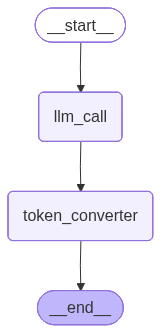

In [12]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [13]:
result = app.invoke({
    "messages": [HumanMessage(content="Hi, this is Sunny. Say hello in detail.")]
})

In [14]:
result

{'messages': [HumanMessage(content='Hi, this is Sunny. Say hello in detail.', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Hello, Sunny! It's wonderful to meet you! I hope you're having a fantastic day. My name is Assistant, and I'm here to help with anything you need—whether it's answering questions, providing support, or just having a friendly conversation. What’s on your mind today? 😊", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 18, 'total_tokens': 75, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-11-20', 'system_fingerprint': 'fp_af7f7349a4', 'id': 'chatcmpl-DD3TYlT1kDhH5sloXKcBKSJIBezid', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered'

In [15]:
for m in result["messages"]:
    print(f"{type(m).__name__}: {m.content}")

HumanMessage: Hi, this is Sunny. Say hello in detail.
AIMessage: Hello, Sunny! It's wonderful to meet you! I hope you're having a fantastic day. My name is Assistant, and I'm here to help with anything you need—whether it's answering questions, providing support, or just having a friendly conversation. What’s on your mind today? 😊
AIMessage: Total token number in the generated answer (word count) is 44


In [16]:
llm

AzureChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000027673B8DE80>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000027673B8E120>, root_client=<openai.lib.azure.AzureOpenAI object at 0x0000027673B7A210>, root_async_client=<openai.lib.azure.AsyncAzureOpenAI object at 0x0000027673B7AE90>, model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True, max_tokens=500, disabled_params={'parallel_tool_calls': None}, azure_endpoint='https://moham-mi3bbwt

In [17]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

api_wrapper = WikipediaAPIWrapper(top_k_results=5, doc_content_chars_max=500)
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper)

In [18]:
wiki_tool.run({"query":"Generative AI"})

'Page: Generative artificial intelligence\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI to'

In [19]:
from langchain_community.tools.tavily_search import TavilySearchResults
tool = TavilySearchResults(tavily_api_key=os.getenv("TAVILY_API_KEY"))
tool.invoke({"query":"how is the job market for fresh graduates in 2026?"})

C:\Users\mohammed.a\AppData\Local\Temp\ipykernel_12648\4118202666.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(tavily_api_key=os.getenv("TAVILY_API_KEY"))


[{'title': 'NACE releases Job Outlook for Class of 2026: Hiring cautious, flat',
  'url': 'https://www.linkedin.com/posts/svanderziel_first-look-hot-off-the-presses-this-week-activity-7394028792970780672-kumX',
  'content': 'looks like Class of 2026 graduates will be entering another competitive job market. Here’s hoping the coming months bring stronger hiring momentum and renewed optimism. You can read the full report for free here:  National Association of Colleges and Employers [...] First look… hot off the presses! This week, we’re releasing NACE’s Job Outlook for the college Class of 2026. The headline: Employers are continuing to hire, but with caution. The vast majority plan to maintain hiring levels consistent with last year’s Class of 2025. We know that opportunities for the Classes of 2024 and 2025 were more limited, and the same forces appear to be at play again: a uncertain economy and reduced business needs (according to employers in our research). Here’s what we’re seeing

In [20]:
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
TAVILY_API_KEY

'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'

In [21]:
from langchain_community.tools import DuckDuckGoSearchRun
search=DuckDuckGoSearchRun()

search.invoke("what is the latest update on iphone17 release?")

Impersonate 'chrome_116' does not exist, using 'random'


'Apple has unveiled four new iPhones: the iPhone 17, iPhone Air, iPhone 17 Pro and iPhone 17 Pro Max. Here\'s the lowdown on the specs, price, new features, design, dimensions and more. Apple launched its new iPhone 17 lineup and ultra-thin iPhone Air in September 2025. The iPhone 17 is Apple\'s most affordable flagship iPhone, sold alongside the higher-end iPhone Air, iPhone 17 ... Discover the iPhone 17\'s groundbreaking features, including brighter displays, reverse wireless charging, and a sleek new design. Apple has unveiled the iPhone 17 during its "Awe Dropping" event, showcasing all the improvements, colors and more. The latest iteration of the iPhone was revealed by Apple on Tuesday, Sept. 9. Here are the key new features, prices, and when you can order one.'

In [22]:
from langchain_community.tools import YouTubeSearchTool

In [23]:
tool = YouTubeSearchTool()

In [24]:
tool.name

'youtube_search'

In [25]:
tool.description

'search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional'

In [26]:
tool.run('krish naik')

SSLError: HTTPSConnectionPool(host='youtube.com', port=443): Max retries exceeded with url: /results?search_query=krish+naik (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1032)')))

In [31]:
def multiply(a: int, b: int):
    return a*b

In [32]:
multiply(10,20)

200

In [33]:
multiply.invoke(10,20)

AttributeError: 'function' object has no attribute 'invoke'

In [34]:
from langchain.tools import tool

@tool
def multiply(a: int, b: int)-> int:
    '''this tool is for the multiplication'''
    return a*b

In [35]:
multiply.invoke({"a":10,"b":20})

200

In [36]:
multiply.name

'multiply'

In [37]:
multiply.description

'this tool is for the multiplication'

In [38]:
multiply.args

{'a': {'title': 'A', 'type': 'integer'},
 'b': {'title': 'B', 'type': 'integer'}}

In [39]:
@tool
def get_word_length(word: str) -> int:
    """it is a tool to count the length of the word"""
    return len(word)

In [40]:
get_word_length.invoke("Sam")

3

In [41]:
get_word_length.invoke("Hello world")

11

In [42]:
@tool
def call_gmail_api(args):
    """this is a tool to call gmail api""" 
    pass

In [43]:
import yfinance as yf

In [73]:
@tool
def get_stock_price(ticker:str) -> str: 
    """this is a tool to get stock price using yfinance"""
    try:
        stock = yf.Ticker(ticker)

        # Get last 1 day historical data
        data = stock.history(period="1d")

        if data.empty:
            return f"No data found for ticker '{ticker}'. Please check the symbol."

        latest_close = data["Close"].iloc[-1]

        # Detect currency
        currency = stock.info.get("currency", "")
        symbol_map = {
            "INR": "₹",
            "USD": "$",
            "EUR": "€",
            "GBP": "£"
        }

        symbol = symbol_map.get(currency, "")
        currency_text = currency if currency else ""

        if symbol:
            return f"The last closing price of {ticker.upper()} was {symbol}{latest_close:.2f}."
        else:
            return f"The last closing price of {ticker.upper()} was {latest_close:.2f} {currency_text}."

    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"

In [74]:
get_stock_price.invoke("TCS.NS")

"An error occurred while fetching stock data: 'NoneType' object is not subscriptable"

In [46]:
get_stock_price.invoke("AAPL")

"An error occurred while fetching stock data: 'NoneType' object is not subscriptable"

In [47]:
get_stock_price.invoke("TSLA")

"An error occurred while fetching stock data: 'NoneType' object is not subscriptable"

In [48]:
get_stock_price.invoke("HDFCBANK.NS")

"An error occurred while fetching stock data: 'NoneType' object is not subscriptable"

In [49]:
[get_stock_price, get_word_length, multiply]

[StructuredTool(name='get_stock_price', description='this is a tool to get stock price using yfinance', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x0000027615C40AE0>),
 StructuredTool(name='get_word_length', description='it is a tool to count the length of the word', args_schema=<class 'langchain_core.utils.pydantic.get_word_length'>, func=<function get_word_length at 0x0000027677980E00>),
 StructuredTool(name='multiply', description='this tool is for the multiplication', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x00000276778F28E0>)]

In [50]:
tools = [get_stock_price, get_word_length, multiply, wiki_tool]

In [51]:
llm_with_tool = llm.bind_tools(tools=tools)

In [52]:
result =llm_with_tool.invoke("what is the stock price of TCS.NS?")
result.content

''

In [53]:
result.tool_calls

[{'name': 'get_stock_price',
  'args': {'ticker': 'TCS.NS'},
  'id': 'call_479E4VCKKYcB0ULfHtux3k5K',
  'type': 'tool_call'}]

In [54]:
result = llm_with_tool.invoke("how many words are there in the sentence 'hello world, this is a test sentence?'")

In [55]:
result.content

''

In [56]:
result.tool_calls

[{'name': 'get_word_length',
  'args': {'word': 'hello'},
  'id': 'call_P8VfI7mwmd6yp7ShXoWZRH4D',
  'type': 'tool_call'}]

In [57]:
result = llm_with_tool.invoke("can you multiply 10 and 20?")
result.content

''

In [58]:
result.tool_calls

[{'name': 'multiply',
  'args': {'a': 10, 'b': 20},
  'id': 'call_mfa9W4FDmqCT9tqylgWjLwgF',
  'type': 'tool_call'}]

In [59]:
result = llm_with_tool.invoke("Hi")
result.content

'Hello! How can I assist you today?'

In [60]:
result.tool_calls

[]

In [61]:
result = llm_with_tool.invoke(("what was in the latest indian union budget report of 2026?"))

In [62]:
result.content

''

In [63]:
result.tool_calls

[{'name': 'wikipedia',
  'args': {'query': '2026 Indian Union Budget'},
  'id': 'call_A3kwReRNEaycUbczDelCkPTL',
  'type': 'tool_call'}]

In [64]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState, StateGraph, END, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [65]:
SYSTEM_PROMPT = SystemMessage(content="You are a helpful assistant that can use tools to answer questions.")

def function_1(state:MessagesState):
    user_question = state["messages"]
    input_question = [SYSTEM_PROMPT]+user_question
    response = llm_with_tool.invoke(input_question)
    return{
        "messages":[response]
    }

In [66]:
function_2 = ToolNode(tools)

In [67]:
workflow = StateGraph(MessagesState)
workflow.add_node("llm",function_1)
workflow.add_node("tools", function_2)

workflow.add_edge(START,"llm")
workflow.add_conditional_edges("llm", tools_condition)
workflow.add_edge("tools","llm")

app = workflow.compile()

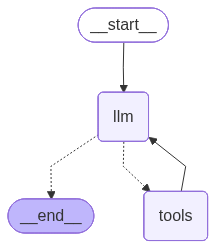

In [68]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [71]:
result = app.invoke({
    "messages":[HumanMessage(content="what is the stock price of TCS?")]
})

Failed to get ticker 'TCS' reason: Failed to perform, curl: (60) SSL certificate problem: unable to get local issuer certificate. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.


In [72]:
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the stock price of TCS?
================================== Ai Message ==================================
Tool Calls:
  get_stock_price (call_uRLjQFoqhNjIp4iJGPIuCRVY)
 Call ID: call_uRLjQFoqhNjIp4iJGPIuCRVY
  Args:
    ticker: TCS
================================= Tool Message =================================
Name: get_stock_price

An error occurred while fetching stock data: Failed to perform, curl: (60) SSL certificate problem: unable to get local issuer certificate. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
================================== Ai Message ==================================

I'm unable to fetch the stock price for TCS at the moment due to an issue with the data source. You may want to check stock prices directly from reliable platforms like market tracking websites or apps.


In [75]:
result = app.invoke({
    "messages": [HumanMessage(content="what was in the latest indian union budget report of 2026?")]
})

In [76]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

what was in the latest indian union budget report of 2026?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_gqLpkWrcxd7zxuPguLLq4tXZ)
 Call ID: call_gqLpkWrcxd7zxuPguLLq4tXZ
  Args:
    query: latest Indian Union Budget of 2026
================================= Tool Message =================================
Name: wikipedia

Page: Union budget of India
Summary: The Union Budget of India, also known as the Annual Financial Statement under Article 112 of the Indian Constitution, is the country's annual financial plan prepared by the Ministry of Finance. It outlines the government's expected revenues, collected by the Department of Revenue, and planned expenditures, managed by the Department of Expenditure. The budget serves as a financial blueprint for the upcoming fiscal year, forecasting economic conditions and alig
=============================

In [77]:
result = app.invoke({
    "messages": [HumanMessage(content="give me the latest AI news count the length of response and multiply that response with the 10.")]
})

In [78]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

give me the latest AI news count the length of response and multiply that response with the 10.
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_04SJz3JLO2nCWfMlVs2M06cR)
 Call ID: call_04SJz3JLO2nCWfMlVs2M06cR
  Args:
    query: latest AI news
================================= Tool Message =================================
Name: wikipedia

Page: Mistral AI
Summary: Mistral AI SAS (French: [mistʁal]) is a French artificial intelligence (AI) company, headquartered in Paris. Founded in 2023, it has open-weight large language models (LLMs), with both open-source and proprietary AI models. As of 2025 the company has a valuation of more than US$14 billion.

Page: AI slop
Summary: AI slop (also known simply as slop) is digital content made with generative artificial intelligence that is perceived as lacking in effort, quality, or meaning
============

In [79]:
result = app.invoke({
    "messages": [HumanMessage(content="how did trump's tariff policy impact the TCS.NS?")]
})

In [80]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

how did trump's tariff policy impact the TCS.NS?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_sZPR2JR66FzkFSzODfzGkVcS)
 Call ID: call_sZPR2JR66FzkFSzODfzGkVcS
  Args:
    query: Donald Trump tariff policy
  get_stock_price (call_rL3R7brVuICd54pcHbCSrn4V)
 Call ID: call_rL3R7brVuICd54pcHbCSrn4V
  Args:
    ticker: TCS.NS
================================= Tool Message =================================
Name: wikipedia

Page: Tariffs in the second Trump administration
Summary: During his second term as President of the United States, Donald Trump enacted a series of steep tariffs affecting nearly all goods imported into the country. From January to April 2025, the overall average effective US tariff rate rose from 2.5% to an estimated 27%—the highest level in over a century. After changes, negotiations, and the invalidation of certain tariffs 